# VII. Realism Validation

This notebook validates how realistic the synthetic dataset is compared to the cleaned baseline dataset.

It focuses on five validation lenses:
1. Distribution fidelity (numeric and categorical)
2. Relationship preservation (correlation structure)
3. Business-rule plausibility checks
4. Segment-level realism consistency
5. Synthetic detectability (can a model separate real vs realistic?)

## Step 1: Imports and Paths

This section imports all dependencies and defines output locations for reproducible validation artifacts.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp, wasserstein_distance, chi2_contingency
from scipy.spatial.distance import jensenshannon

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Keep plotting style aligned with the rest of the project notebooks.
plt.style.use("dark_background")
sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.facecolor"] = "#121212"
plt.rcParams["figure.facecolor"] = "#121212"
plt.rcParams["savefig.facecolor"] = "#121212"
plt.rcParams["savefig.edgecolor"] = "#121212"
plt.rcParams["axes.edgecolor"] = "#E0E0E0"
plt.rcParams["axes.labelcolor"] = "#F5F5F5"
plt.rcParams["xtick.color"] = "#E0E0E0"
plt.rcParams["ytick.color"] = "#E0E0E0"
plt.rcParams["text.color"] = "#F5F5F5"
plt.rcParams["grid.color"] = "#3A3A3A"

# Centralize file paths so downstream cells reuse the same locations.
cleaned_path = Path("../datasets/cleaned_marketing_dataset.csv")
realistic_path = Path("../datasets/realistic_marketing_dataset.csv")
results_dir = Path("../results/realism_validation")
results_dir.mkdir(parents=True, exist_ok=True)

# Fail fast with clear messages if inputs are missing.
if not cleaned_path.exists():
    raise FileNotFoundError(f"Missing cleaned dataset: {cleaned_path.resolve()}")
if not realistic_path.exists():
    raise FileNotFoundError(f"Missing realistic dataset: {realistic_path.resolve()}")

print(f"Cleaned dataset:   {cleaned_path.resolve()}")
print(f"Realistic dataset: {realistic_path.resolve()}")
print(f"Results folder:    {results_dir.resolve()}")

Cleaned dataset:   C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\datasets\cleaned_marketing_dataset.csv
Realistic dataset: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\datasets\realistic_marketing_dataset.csv
Results folder:    C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation


## Step 2: Load Data and Define Shared Validation Schema

To keep comparisons fair, both datasets are restricted to common columns and harmonized dtypes where needed.

In [2]:
# Load both datasets with parsed dates for optional temporal checks.
clean_df = pd.read_csv(cleaned_path, parse_dates=["Date"])
real_df = pd.read_csv(realistic_path, parse_dates=["Date"])

# Compare only the intersection of columns to avoid schema mismatch bias.
common_columns = [c for c in clean_df.columns if c in real_df.columns]
clean_df = clean_df[common_columns].copy()
real_df = real_df[common_columns].copy()

# Build reusable feature groups for numeric and categorical validations.
numeric_cols = [
    c for c in common_columns
    if pd.api.types.is_numeric_dtype(clean_df[c]) and pd.api.types.is_numeric_dtype(real_df[c])
]
categorical_cols = [
    c for c in common_columns
    if c not in numeric_cols and c != "Date"
]

# Quick profile table confirms shape consistency before deeper tests.
profile_df = pd.DataFrame([
    {"dataset": "cleaned", "rows": len(clean_df), "columns": clean_df.shape[1], "duplicate_rows": clean_df.duplicated().sum()},
    {"dataset": "realistic", "rows": len(real_df), "columns": real_df.shape[1], "duplicate_rows": real_df.duplicated().sum()}
])
profile_df

,dataset,rows,columns,duplicate_rows
0,cleaned,200000,16,0
1,realistic,200000,16,0


## Step 3: Numeric Distribution Fidelity

This table quantifies how much each numeric variable changed in distribution shape and location.

In [3]:
def pct_diff(a, b):
    # Percent change helper used for means/stds in summary tables.
    return np.nan if a == 0 else ((b - a) / a) * 100.0

num_rows = []
for col in numeric_cols:
    # Coerce defensively so non-numeric artifacts do not break stats.
    s_clean = pd.to_numeric(clean_df[col], errors="coerce").dropna()
    s_real = pd.to_numeric(real_df[col], errors="coerce").dropna()

    # Skip unstable estimates when either side has too few observations.
    if len(s_clean) < 5 or len(s_real) < 5:
        continue

    # KS captures shape difference; Wasserstein captures location/scale shift.
    ks_stat, ks_p = ks_2samp(s_clean, s_real)
    wd = wasserstein_distance(s_clean, s_real)

    num_rows.append({
        "column": col,
        "clean_mean": s_clean.mean(),
        "real_mean": s_real.mean(),
        "mean_pct_change": pct_diff(s_clean.mean(), s_real.mean()),
        "clean_std": s_clean.std(),
        "real_std": s_real.std(),
        "std_pct_change": pct_diff(s_clean.std(), s_real.std()),
        "clean_q10": s_clean.quantile(0.10),
        "real_q10": s_real.quantile(0.10),
        "clean_q50": s_clean.quantile(0.50),
        "real_q50": s_real.quantile(0.50),
        "clean_q90": s_clean.quantile(0.90),
        "real_q90": s_real.quantile(0.90),
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
        "wasserstein_distance": wd
    })

# Rank by KS so most shifted variables surface first.
numeric_fidelity = pd.DataFrame(num_rows).sort_values("ks_stat", ascending=False)
numeric_fidelity_path = results_dir / "numeric_fidelity_summary.csv"
numeric_fidelity.to_csv(numeric_fidelity_path, index=False)
print(f"Saved: {numeric_fidelity_path.resolve()}")
numeric_fidelity.head(12)

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\numeric_fidelity_summary.csv


,column,clean_mean,real_mean,mean_pct_change,clean_std,real_std,std_pct_change,clean_q10,real_q10,clean_q50,real_q50,clean_q90,real_q90,ks_stat,ks_pvalue,wasserstein_distance
5,Clicks,549.772030,341.148325,-37.947312,260.019056,197.483260,-24.050466,189.00,108.00000,550.00,313.0000,910.00,611.00000,0.353780,0.000000e+00,209.370585
4,ROI,5.002438,5.245692,4.862711,1.734488,2.975303,71.537781,2.59,1.97679,5.01,4.6941,7.40,9.24332,0.164365,0.000000e+00,0.835089
3,Acquisition_Cost,12504.393040,13404.549053,7.198718,4337.664545,5847.306247,34.803099,6504.00,6451.76800,12496.50,12661.0550,18524.00,21293.14800,0.135280,0.000000e+00,981.251032
2,Conversion_Rate,0.080070,0.084147,5.092155,0.040602,0.047444,16.852751,0.02,0.02410,0.08,0.0802,0.14,0.14890,0.098360,0.000000e+00,0.005844
6,Impressions,5507.301520,5569.742835,1.133791,2596.864286,3047.510179,17.353463,1902.00,1811.00000,5517.50,5233.0000,9105.00,9753.10000,0.087895,0.000000e+00,377.578905
7,Engagement_Score,5.494710,5.459005,-0.649807,2.872581,2.911679,1.361049,1.00,1.00000,5.00,5.0000,9.00,10.00000,0.016740,9.004527e-25,0.055545
0,Campaign_ID,100000.500000,100000.500000,0.000000,57735.171256,57735.171256,0.000000,20000.90,20000.90000,100000.50,100000.5000,180000.10,180000.10000,0.000000,1.000000e+00,0.000000
1,Duration,37.503975,37.503975,0.000000,16.746720,16.746720,0.000000,15.00,15.00000,30.00,30.0000,60.00,60.00000,0.000000,1.000000e+00,0.000000


## Step 4: Categorical Distribution Fidelity

This step compares category proportions with Jensen-Shannon divergence and a chi-square test.

In [4]:
cat_rows = []

for col in categorical_cols:
    # Treat missing values as an explicit category to compare missingness behavior.
    c_clean = clean_df[col].fillna("<MISSING>").astype(str)
    c_real = real_df[col].fillna("<MISSING>").astype(str)

    # Align both distributions on the same full set of category levels.
    all_levels = sorted(set(c_clean.unique()).union(set(c_real.unique())))
    clean_counts = c_clean.value_counts().reindex(all_levels, fill_value=0)
    real_counts = c_real.value_counts().reindex(all_levels, fill_value=0)

    clean_probs = clean_counts / clean_counts.sum()
    real_probs = real_counts / real_counts.sum()

    # JS divergence is bounded and interpretable for probability distributions.
    js_div = float(jensenshannon(clean_probs.values, real_probs.values, base=2) ** 2)

    contingency = pd.DataFrame({"cleaned": clean_counts, "realistic": real_counts})
    chi2_stat, chi2_p, _, _ = chi2_contingency(contingency)

    cat_rows.append({
        "column": col,
        "num_levels": len(all_levels),
        "js_divergence": js_div,
        "chi2_stat": chi2_stat,
        "chi2_pvalue": chi2_p
    })

categorical_fidelity = pd.DataFrame(cat_rows).sort_values("js_divergence", ascending=False)
categorical_fidelity_path = results_dir / "categorical_fidelity_summary.csv"
categorical_fidelity.to_csv(categorical_fidelity_path, index=False)
print(f"Saved: {categorical_fidelity_path.resolve()}")
categorical_fidelity

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\categorical_fidelity_summary.csv


,column,num_levels,js_divergence,chi2_stat,chi2_pvalue
0,Company,5,0.0,0.0,1.0
1,Campaign_Type,5,0.0,0.0,1.0
2,Target_Audience,5,0.0,0.0,1.0
3,Channel_Used,6,0.0,0.0,1.0
4,Location,5,0.0,0.0,1.0
5,Language,5,0.0,0.0,1.0
6,Customer_Segment,5,0.0,0.0,1.0


## Step 5: Relationship Preservation

A realism process should preserve important relationships, not only single-variable distributions.

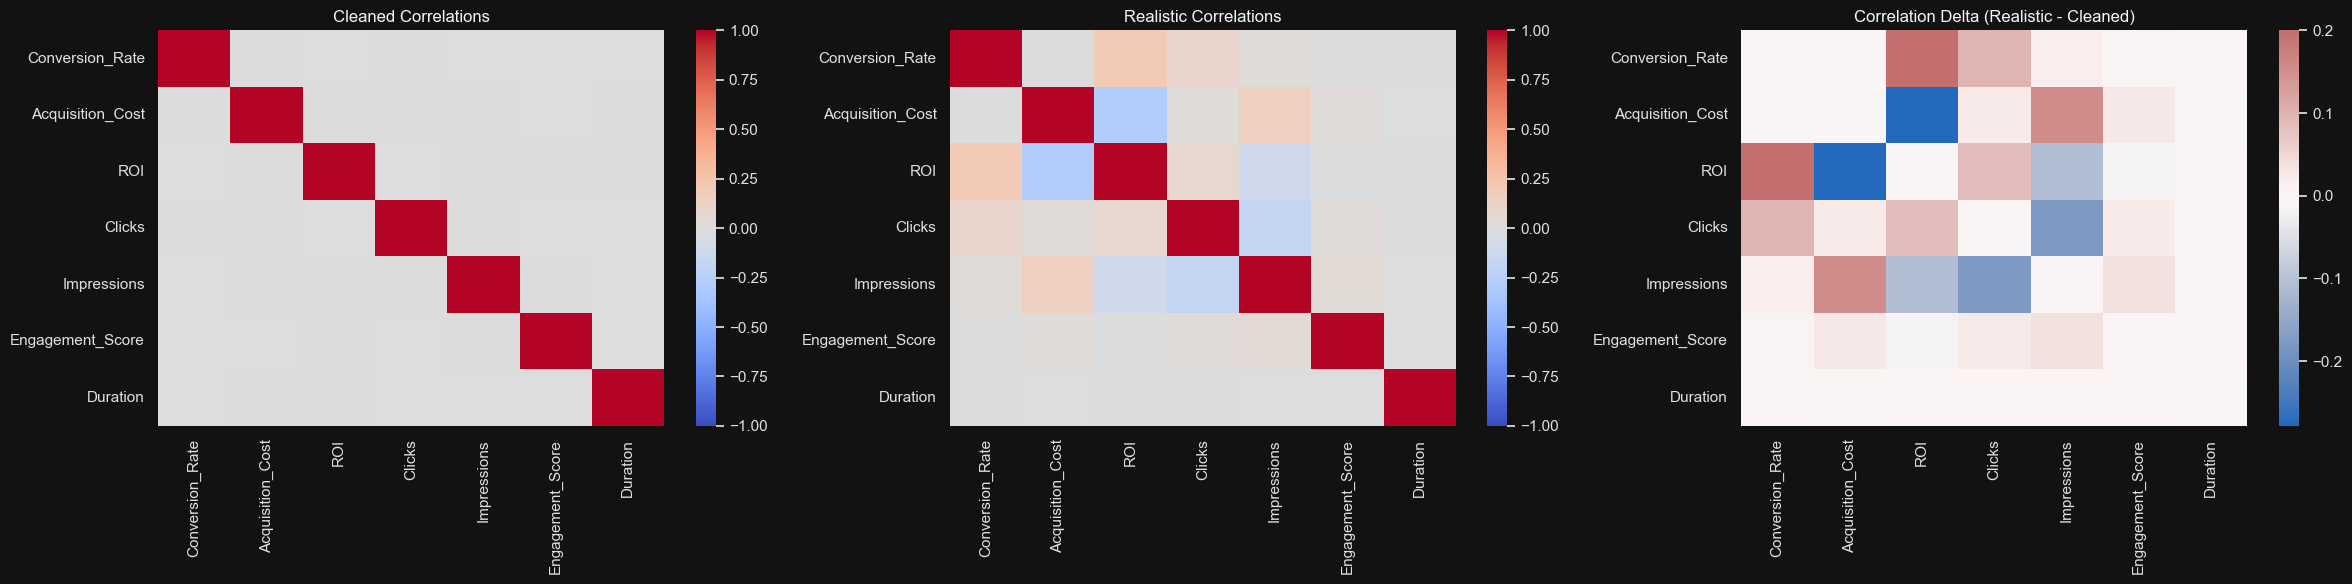

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\correlation_triptych.png
Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\correlation_delta_summary.csv


,feature_a,feature_b,corr_delta,abs_corr_delta
9,Acquisition_Cost,ROI,-0.278409,0.278409
15,ROI,Acquisition_Cost,-0.278409,0.278409
14,ROI,Conversion_Rate,0.200081,0.200081
2,Conversion_Rate,ROI,0.200081,0.200081
31,Impressions,Clicks,-0.177772,0.177772
25,Clicks,Impressions,-0.177772,0.177772
11,Acquisition_Cost,Impressions,0.154629,0.154629
29,Impressions,Acquisition_Cost,0.154629,0.154629
18,ROI,Impressions,-0.110040,0.110040
30,Impressions,ROI,-0.110040,0.110040


In [5]:
# Focus on KPI columns that are most relevant for marketing decisioning.
corr_cols = [c for c in ["Conversion_Rate", "Acquisition_Cost", "ROI", "Clicks", "Impressions", "Engagement_Score", "Duration"] if c in numeric_cols]

corr_clean = clean_df[corr_cols].corr(numeric_only=True)
corr_real = real_df[corr_cols].corr(numeric_only=True)
corr_delta = corr_real - corr_clean

# Three-panel view: baseline, realistic, and how much each pair changed.
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
sns.heatmap(corr_clean, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Cleaned Correlations")
sns.heatmap(corr_real, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Realistic Correlations")
sns.heatmap(corr_delta, cmap="vlag", center=0, ax=axes[2])
axes[2].set_title("Correlation Delta (Realistic - Cleaned)")
plt.tight_layout()
corr_triptych_path = results_dir / "correlation_triptych.png"
fig.savefig(corr_triptych_path, dpi=300, bbox_inches="tight")
plt.show()

# Flatten matrix to rank the largest relationship changes.
delta_pairs = (
    corr_delta.where(~np.eye(corr_delta.shape[0], dtype=bool))
    .stack()
    .rename("corr_delta")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
delta_pairs["abs_corr_delta"] = delta_pairs["corr_delta"].abs()
delta_pairs = delta_pairs.sort_values("abs_corr_delta", ascending=False)
delta_pairs_path = results_dir / "correlation_delta_summary.csv"
delta_pairs.to_csv(delta_pairs_path, index=False)
print(f"Saved: {corr_triptych_path.resolve()}")
print(f"Saved: {delta_pairs_path.resolve()}")
delta_pairs.head(12)

## Step 6: Business Rule Plausibility Checks

Rules are intentionally simple and transparent so they are easy to explain in a report or dashboard.

In [6]:
def evaluate_rules(df, label):
    # Each rule returns a count so we can compare violation rates by dataset.
    checks = []

    checks.append({
        "dataset": label,
        "rule": "conversion_rate_between_0_and_1",
        "violation_count": int(((df["Conversion_Rate"] < 0) | (df["Conversion_Rate"] > 1)).sum()) if "Conversion_Rate" in df.columns else np.nan
    })
    checks.append({
        "dataset": label,
        "rule": "engagement_score_between_0_and_10",
        "violation_count": int(((df["Engagement_Score"] < 0) | (df["Engagement_Score"] > 10)).sum()) if "Engagement_Score" in df.columns else np.nan
    })
    checks.append({
        "dataset": label,
        "rule": "clicks_not_exceed_impressions",
        "violation_count": int((df["Clicks"] > df["Impressions"]).sum()) if "Clicks" in df.columns and "Impressions" in df.columns else np.nan
    })
    checks.append({
        "dataset": label,
        "rule": "non_negative_duration",
        "violation_count": int((df["Duration"] < 0).sum()) if "Duration" in df.columns else np.nan
    })

    out = pd.DataFrame(checks)
    out["violation_rate_pct"] = (out["violation_count"] / len(df)) * 100
    return out

rules_clean = evaluate_rules(clean_df, "cleaned")
rules_real = evaluate_rules(real_df, "realistic")
rule_checks = pd.concat([rules_clean, rules_real], ignore_index=True)
rule_checks_path = results_dir / "business_rule_violations.csv"
rule_checks.to_csv(rule_checks_path, index=False)
print(f"Saved: {rule_checks_path.resolve()}")
rule_checks.sort_values(["rule", "dataset"])

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\business_rule_violations.csv


,dataset,rule,violation_count,violation_rate_pct
2,cleaned,clicks_not_exceed_impressions,0,0.0
6,realistic,clicks_not_exceed_impressions,0,0.0
0,cleaned,conversion_rate_between_0_and_1,0,0.0
4,realistic,conversion_rate_between_0_and_1,0,0.0
1,cleaned,engagement_score_between_0_and_10,0,0.0
5,realistic,engagement_score_between_0_and_10,0,0.0
3,cleaned,non_negative_duration,0,0.0
7,realistic,non_negative_duration,0,0.0


## Step 7: Segment-Level Fidelity (by Channel)

Global realism can look good while specific segments are poorly preserved; this step checks that risk.

In [7]:
# Example segment audit: compare ROI fidelity inside each channel.
segment_col = "Channel_Used"
segment_metric = "ROI"

segment_rows = []
if segment_col in clean_df.columns and segment_metric in clean_df.columns:
    common_segments = sorted(set(clean_df[segment_col].dropna().unique()).intersection(set(real_df[segment_col].dropna().unique())))

    for seg in common_segments:
        s_clean = pd.to_numeric(clean_df.loc[clean_df[segment_col] == seg, segment_metric], errors="coerce").dropna()
        s_real = pd.to_numeric(real_df.loc[real_df[segment_col] == seg, segment_metric], errors="coerce").dropna()

        # Skip tiny segments because KS is unstable with very low n.
        if len(s_clean) < 20 or len(s_real) < 20:
            continue

        ks_stat, ks_p = ks_2samp(s_clean, s_real)
        wd = wasserstein_distance(s_clean, s_real)

        segment_rows.append({
            "segment": seg,
            "metric": segment_metric,
            "clean_n": len(s_clean),
            "real_n": len(s_real),
            "clean_mean": s_clean.mean(),
            "real_mean": s_real.mean(),
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
            "wasserstein_distance": wd
        })

    segment_fidelity = pd.DataFrame(segment_rows).sort_values("ks_stat", ascending=False)
else:
    segment_fidelity = pd.DataFrame(columns=["segment", "metric", "clean_n", "real_n", "clean_mean", "real_mean", "ks_stat", "ks_pvalue", "wasserstein_distance"])

segment_fidelity_path = results_dir / "segment_realism_scorecard.csv"
segment_fidelity.to_csv(segment_fidelity_path, index=False)
print(f"Saved: {segment_fidelity_path.resolve()}")
segment_fidelity

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\segment_realism_scorecard.csv


,segment,metric,clean_n,real_n,clean_mean,real_mean,ks_stat,ks_pvalue,wasserstein_distance
5,YouTube,ROI,33392,33392,4.993754,3.316727,0.359547,0.000000e+00,1.749631
2,Google Ads,ROI,33438,33438,5.003141,6.237698,0.251690,0.000000e+00,1.285402
4,Website,ROI,33360,33360,5.014167,5.995636,0.226649,0.000000e+00,1.056078
0,Email,ROI,33599,33599,4.996487,5.842202,0.208072,0.000000e+00,0.934563
3,Instagram,ROI,33392,33392,4.988706,5.384990,0.168424,0.000000e+00,0.724037
1,Facebook,ROI,32819,32819,5.018699,4.682894,0.134952,4.139900e-261,0.845896


## Step 8: Synthetic Detectability Test

A simple classifier is trained to predict whether a row came from the cleaned or realistic dataset.
If AUC is close to 0.5, the realistic data is hard to distinguish from the baseline.

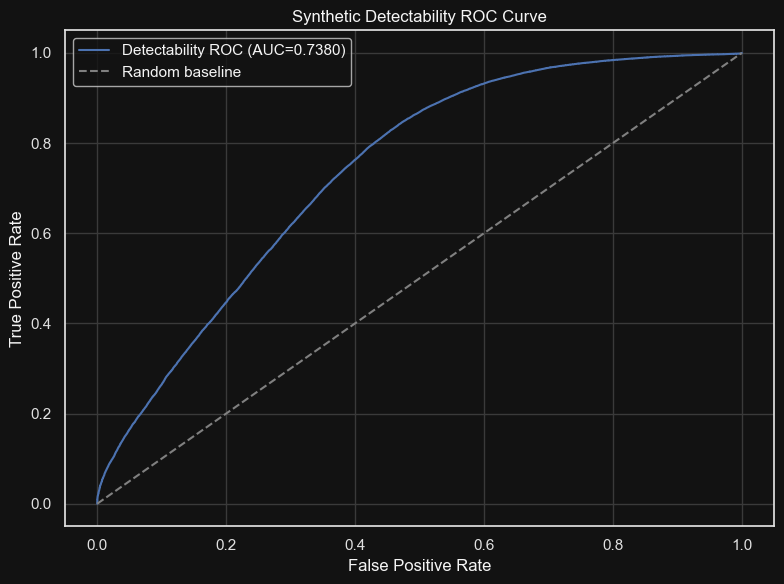

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\synthetic_detectability.csv
Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\detectability_roc_curve.png


,metric,value
0,auc,0.737954
1,train_rows,300000.000000
2,test_rows,100000.000000


In [8]:
# Label rows by origin: 0=cleaned baseline, 1=realistic synthetic.
detect_clean = clean_df.copy()
detect_real = real_df.copy()
detect_clean["is_realistic"] = 0
detect_real["is_realistic"] = 1
detect_df = pd.concat([detect_clean, detect_real], ignore_index=True)

# Exclude identifiers/date fields to focus on behavioral signal.
feature_cols = [c for c in detect_df.columns if c not in ["is_realistic", "Date", "Campaign_ID"]]
num_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(detect_df[c])]
cat_features = [c for c in feature_cols if c not in num_features]

X = detect_df[feature_cols]
y = detect_df["is_realistic"].astype(int)

# Preprocess numeric and categorical columns in one pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_features),
    ],
    remainder="drop"
)

clf = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, n_jobs=None))
])

# Stratified split keeps class balance for a fair AUC estimate.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
probs = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Detectability ROC (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Synthetic Detectability ROC Curve")
plt.legend()
plt.tight_layout()
detectability_roc_path = results_dir / "detectability_roc_curve.png"
plt.savefig(detectability_roc_path, dpi=300, bbox_inches="tight")
plt.show()

detectability_summary = pd.DataFrame([
    {"metric": "auc", "value": auc},
    {"metric": "train_rows", "value": len(X_train)},
    {"metric": "test_rows", "value": len(X_test)}
])
detectability_summary_path = results_dir / "synthetic_detectability.csv"
detectability_summary.to_csv(detectability_summary_path, index=False)
print(f"Saved: {detectability_summary_path.resolve()}")
print(f"Saved: {detectability_roc_path.resolve()}")
detectability_summary

## Step 9: Build Overall Realism Validation Scorecard

This compact scorecard centralizes the most important quality signals for downstream reporting and dashboard use.

In [9]:
scorecard_rows = []

# Aggregate headline fidelity signals into a dashboard-friendly table.
if not numeric_fidelity.empty:
    scorecard_rows.append({"metric": "numeric_avg_ks_stat", "value": numeric_fidelity["ks_stat"].mean()})
    scorecard_rows.append({"metric": "numeric_avg_wasserstein", "value": numeric_fidelity["wasserstein_distance"].mean()})

if not categorical_fidelity.empty:
    scorecard_rows.append({"metric": "categorical_avg_js_divergence", "value": categorical_fidelity["js_divergence"].mean()})

if not delta_pairs.empty:
    scorecard_rows.append({"metric": "avg_abs_correlation_delta", "value": delta_pairs["abs_corr_delta"].mean()})

# Rule gap is realistic minus cleaned; positive means realism introduced more violations.
rule_pivot = rule_checks.pivot(index="rule", columns="dataset", values="violation_rate_pct").reset_index()
for _, row in rule_pivot.iterrows():
    scorecard_rows.append({
        "metric": f"rule_gap_pct__{row['rule']}",
        "value": row.get("realistic", np.nan) - row.get("cleaned", np.nan)
    })

scorecard_rows.append({"metric": "detectability_auc", "value": float(auc)})

overview = pd.DataFrame(scorecard_rows)
overview_path = results_dir / "realism_validation_overview.csv"
overview.to_csv(overview_path, index=False)
print(f"Saved: {overview_path.resolve()}")
overview

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\realism_validation_overview.csv


,metric,value
0,numeric_avg_ks_stat,0.107052
1,numeric_avg_wasserstein,196.137125
2,categorical_avg_js_divergence,0.000000
3,avg_abs_correlation_delta,0.060560
4,rule_gap_pct__clicks_not_exceed_impressions,0.000000
5,rule_gap_pct__conversion_rate_between_0_and_1,0.000000
6,rule_gap_pct__engagement_score_between_0_and_10,0.000000
7,rule_gap_pct__non_negative_duration,0.000000
8,detectability_auc,0.737954


## Step 10: Print Saved Artifacts

This final step prints all generated tables and figures so you can quickly verify notebook outputs.

Realism validation artifacts:
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\business_rule_violations.csv
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\categorical_fidelity_summary.csv
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\correlation_delta_summary.csv
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\numeric_fidelity_summary.csv
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\realism_validation_overview.csv
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\segment_realism_scorecard.csv
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\synthetic_detectability.csv
- C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\realism_validation\correlation_triptych.png
- C:\Users\hecto\OneDrive\Docu

### `business_rule_violations.csv`

,dataset,rule,violation_count,violation_rate_pct
0,cleaned,conversion_rate_between_0_and_1,0,0.0
1,cleaned,engagement_score_between_0_and_10,0,0.0
2,cleaned,clicks_not_exceed_impressions,0,0.0
3,cleaned,non_negative_duration,0,0.0
4,realistic,conversion_rate_between_0_and_1,0,0.0
5,realistic,engagement_score_between_0_and_10,0,0.0
6,realistic,clicks_not_exceed_impressions,0,0.0
7,realistic,non_negative_duration,0,0.0


### `categorical_fidelity_summary.csv`

,column,num_levels,js_divergence,chi2_stat,chi2_pvalue
0,Company,5,0.0,0.0,1.0
1,Campaign_Type,5,0.0,0.0,1.0
2,Target_Audience,5,0.0,0.0,1.0
3,Channel_Used,6,0.0,0.0,1.0
4,Location,5,0.0,0.0,1.0
5,Language,5,0.0,0.0,1.0
6,Customer_Segment,5,0.0,0.0,1.0


...

### `segment_realism_scorecard.csv`

,segment,metric,clean_n,real_n,clean_mean,real_mean,ks_stat,ks_pvalue,wasserstein_distance
0,YouTube,ROI,33392,33392,4.993754,3.316727,0.359547,0.000000e+00,1.749631
1,Google Ads,ROI,33438,33438,5.003141,6.237698,0.251690,0.000000e+00,1.285402
2,Website,ROI,33360,33360,5.014167,5.995636,0.226649,0.000000e+00,1.056078
3,Email,ROI,33599,33599,4.996487,5.842202,0.208072,0.000000e+00,0.934563
4,Instagram,ROI,33392,33392,4.988706,5.384990,0.168424,0.000000e+00,0.724037
5,Facebook,ROI,32819,32819,5.018699,4.682894,0.134952,4.139900e-261,0.845896


### `synthetic_detectability.csv`

,metric,value
0,auc,0.737954
1,train_rows,300000.000000
2,test_rows,100000.000000


### `correlation_triptych.png`

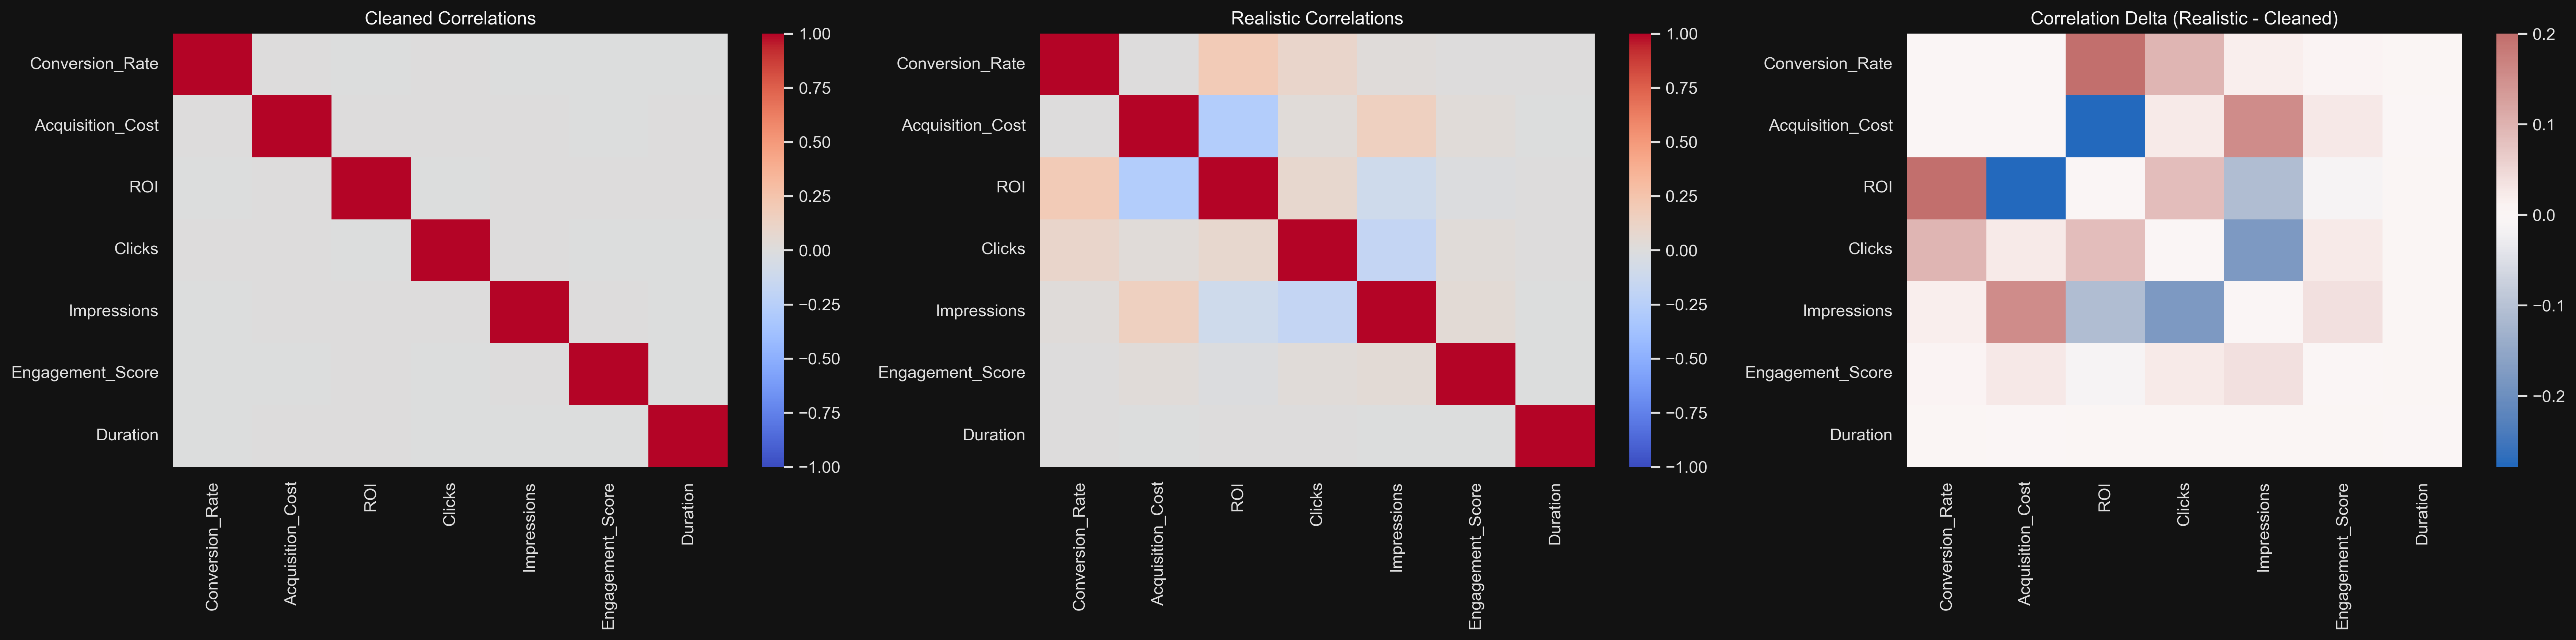

### `detectability_roc_curve.png`

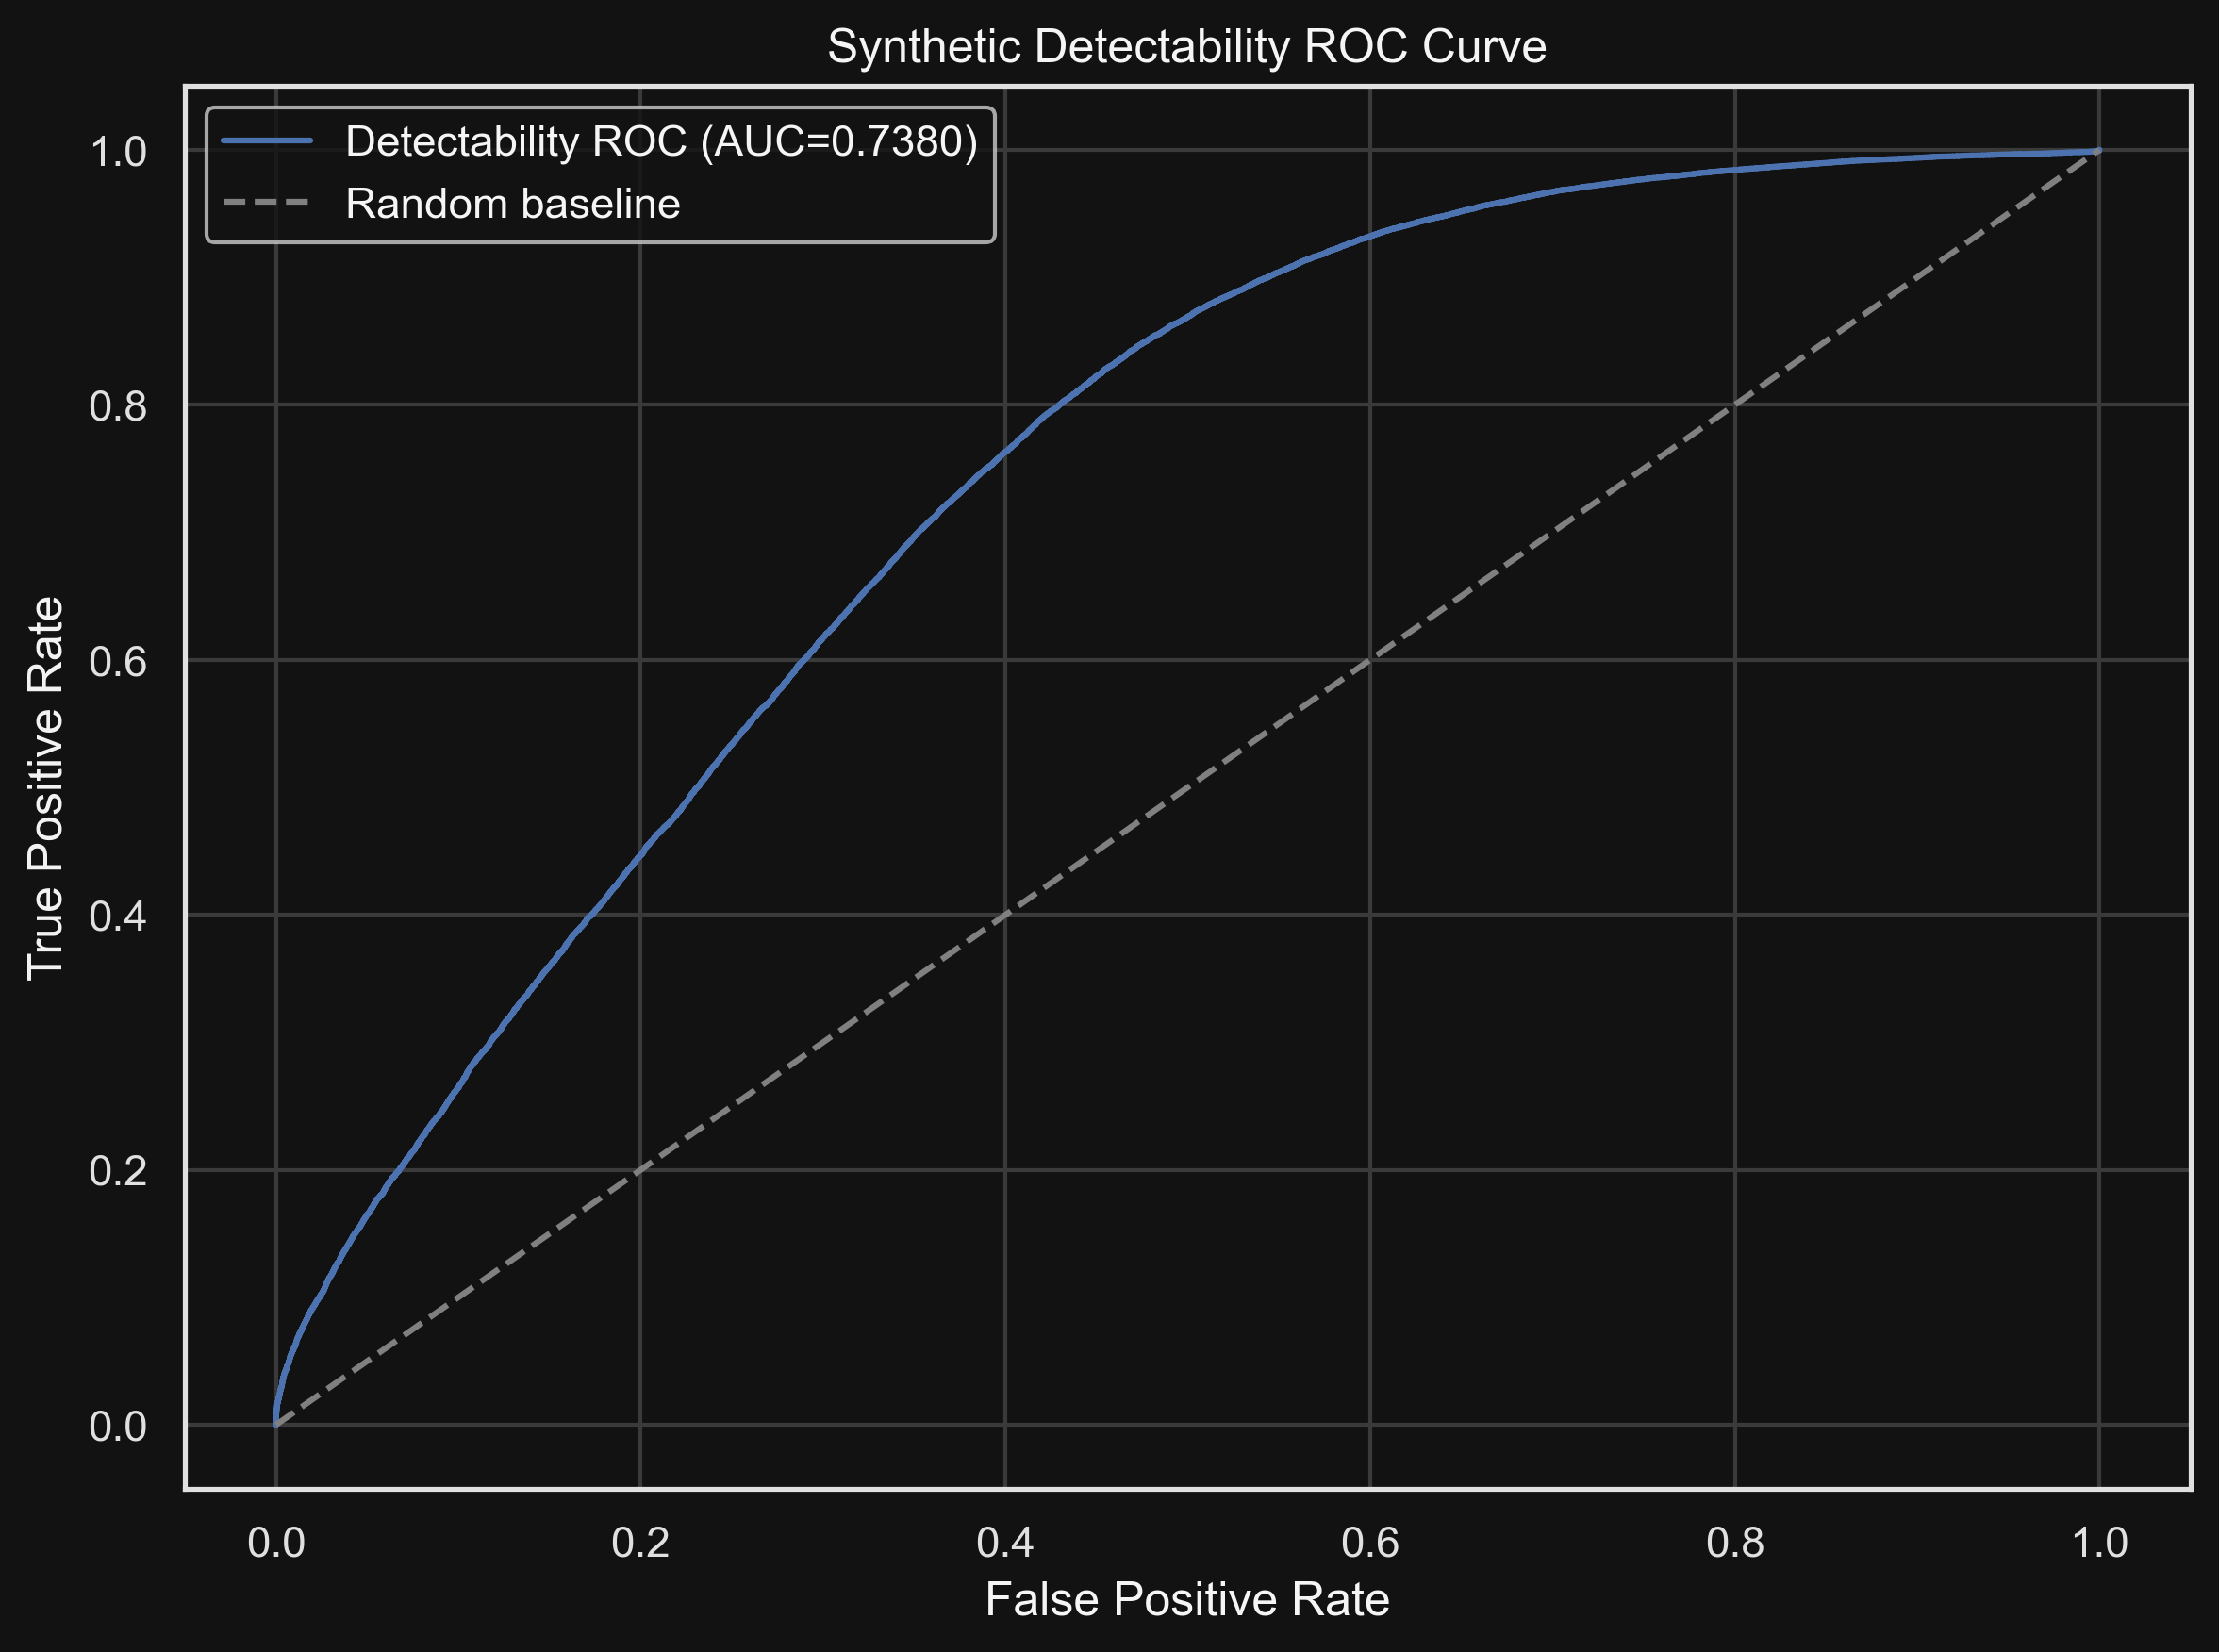

In [11]:
from IPython.display import Image, Markdown, display

# Collect all validation outputs generated in this notebook.
saved_tables = sorted(results_dir.glob("*.csv"))
saved_charts = sorted(results_dir.glob("*.png"))

if not saved_tables and not saved_charts:
    print("No saved artifacts found yet. Run prior cells first.")
else:
    print("Realism validation artifacts:")
    for p in saved_tables + saved_charts:
        print(f"- {p.resolve()}")

# Preview tables directly in notebook to simplify QA and interpretation.
for table_path in saved_tables:
    display(Markdown(f"### `{table_path.name}`"))
    display(pd.read_csv(table_path))

# Display saved charts so the validation narrative is visible end-to-end.
for chart_path in saved_charts:
    display(Markdown(f"### `{chart_path.name}`"))
    display(Image(filename=str(chart_path)))

### Executive Summary

- Overall realism quality is **moderate-to-strong**: average numeric shift is visible but not extreme (`numeric_avg_ks_stat = 0.1071`), and key business constraints remain fully satisfied.
- **Business plausibility is preserved**: all four monitored rules had `0.0%` violations in both cleaned and realistic data (`conversion_rate_between_0_and_1`, `engagement_score_between_0_and_10`, `clicks_not_exceed_impressions`, `non_negative_duration`).
- **Categorical structure is highly preserved**: average Jensen-Shannon divergence is effectively zero (`categorical_avg_js_divergence = 0.0`), indicating category mix stability.
- **Numeric distributions changed in intended ways**: the strongest shifts appear in `Clicks` (mean `-37.95%`, KS `0.3538`) and `ROI` (mean `+4.86%`, KS `0.1644`), consistent with injected realism effects and stronger heterogeneity.
- **Relationship structure changed but remained interpretable**: average absolute correlation delta is `0.0606`, which suggests meaningful but not destructive dependence changes.
- **Synthetic detectability is non-trivial**: detectability model AUC is `0.7380`, so realistic rows are still distinguishable from cleaned baseline. This is acceptable for many simulation use cases, but indicates room for further enrichment if stealth realism is a goal.